# Human-in-the-Loop Validation for AI-Driven Intrusion Detection
### Sehrish Shahid (12011153) | Bahrain Polytechnic

Implements and evaluates a human-in-the-loop (HITL) validation framework for multiclass
network intrusion detection on the corrected CSE-CIC-IDS2018 release.

**Pipeline**

| Stage | Purpose | Objective |
|---|---|---|
| 1–3 | Setup, configuration, sampling | — |
| 4–5 | Feature selection, deduplication, partitioning | — |
| 6–7 | XGBoost baseline and evaluation | O1 |
| 8 | Probability calibration | O1 |
| 9 | SHAP explanations and concentration metric | O1 |
| 10–11 | Routing threshold and decision gate | O2 |
| 12–13 | Simulated analyst and retraining | O2 |
| 14 | AI-only vs HITL comparison | O3 |
| 15 | Cross-validation and significance testing | O4 |
| 16 | Explanation stability across folds | — |
| 17 | Augmentation control | — |
| 18–19 | Label-noise robustness, multi-seed replication | — |
| 20–22 | Saving, run log, reloading | — |

**Two sampling profiles** are supported. `balanced` caps dominant classes so no single class
overwhelms the sample; `unbalanced` preserves the population's true class proportions, with
benign traffic at roughly 94%. Both are reported, since the appropriate metrics differ.

**Before running:** download the corrected CSE-CIC-IDS2018 CSVs and set `DATA_DIR` in Section 2.

## 1. Setup

Imports and the global random seed. Run once per session.

In [1]:
# Fresh environment (e.g. Colab): uncomment
# !pip install xgboost shap scikit-learn pandas numpy scipy matplotlib joblib -q

import os, glob, json, warnings, joblib
from datetime import datetime
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             matthews_corrcoef, confusion_matrix, classification_report)
from scipy import stats
from scipy.stats import spearmanr, kendalltau
import xgboost as xgb
import shap

try:
    from sklearn.frozen import FrozenEstimator
    HAS_FROZEN = True
except ImportError:
    HAS_FROZEN = False

warnings.filterwarnings("ignore")
SEED = 42
RNG = np.random.default_rng(SEED)
np.random.seed(SEED)
print("xgboost", xgb.__version__, "| shap", shap.__version__,
      "| FrozenEstimator", HAS_FROZEN)

xgboost 3.2.0 | shap 0.51.0 | FrozenEstimator True


## 2. Configuration

**Sampling profiles.** `balanced` applies a cap so the dominant classes do not overwhelm the
sample; the resulting dataset is close to balanced and macro-averaged metrics are meaningful
without adjustment. `unbalanced` preserves the population's class proportions, producing a
dataset in which benign traffic is roughly 94% — realistic operational composition, and a
substantially harder classification problem.

**Run versioning.** Each execution writes to its own timestamped directory, so no previous
result is overwritten and runs can be compared afterwards.

**Caching.** The population label scan and the sampled dataset are both cached to disk. The
35 GB scan therefore runs once per profile rather than on every execution.

In [2]:
DATA_DIR     = "./data/CSECICIDS2018_improved"   # folder of corrected CSE-CIC-IDS2018 CSVs
RESULTS_ROOT = "./results_reproduction"

# ---- Sampling profile ----
SAMPLING_PROFILE = "unbalanced"        # "balanced" or "unbalanced"

if SAMPLING_PROFILE == "balanced":
    SAMPLE_FRACTION, MAX_PER_CLASS, MIN_PER_CLASS = 0.10, 100_000, 1_000
elif SAMPLING_PROFILE == "unbalanced":
    SAMPLE_FRACTION, MAX_PER_CLASS, MIN_PER_CLASS = 0.0055, None, 50
else:
    raise ValueError("SAMPLING_PROFILE must be 'balanced' or 'unbalanced'")

MIN_CLASS_SIZE   = 50      # classes below this in the POPULATION are excluded
ATTEMPTED_POLICY = "keep"  # "keep" | "merge" | "drop"
CACHE_POP_COUNTS = True
CACHE_SAMPLE     = True

ANALYST_ERROR_MODEL = "pessimistic"
NOISE_ANALYST_MODEL = "pessimistic"
RUN_NAME = "run_unbalanced_pessimistic_seed42_reproduction"

# ---- Partitioning ----
TEST_SIZE, VAL_SIZE = 0.20, 0.20

# ---- Decision gate ----
ROUTE_BUDGET            = 0.05   # analyst capacity: least-confident share routed
CONCENTRATION_THRESHOLD = 0.15   # min share of total |SHAP| held by the top feature

# ---- Simulated analyst ----
ANALYST_ERROR_RATE = 0.10

# ---- Evaluation ----
N_CV_FOLDS = 5

# ---- Run directory ----
RUN_NAME = "run_unbalanced_pessimistic_seed42_reproduction"

OUTPUT_DIR = os.path.join(RESULTS_ROOT, RUN_NAME)
SAMPLE_PATH = os.path.join(
    RESULTS_ROOT,
    f"sampled_{SAMPLING_PROFILE}.csv"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Profile     : {SAMPLING_PROFILE}  (fraction={SAMPLE_FRACTION}, "
      f"cap={MAX_PER_CLASS}, floor={MIN_PER_CLASS})")
print(f"Data        : {os.path.abspath(DATA_DIR)}")
print(f"Sample cache: {SAMPLE_PATH}")
print(f"Output      : {os.path.abspath(OUTPUT_DIR)}")

Profile     : unbalanced  (fraction=0.0055, cap=None, floor=50)
Data        : c:\Users\seri\Desktop\MSC. AI\Thesis\Thesis Project - HITL vs AI\HITLV2\data\CSECICIDS2018_improved
Sample cache: ./results_reproduction\sampled_unbalanced.csv
Output      : c:\Users\seri\Desktop\MSC. AI\Thesis\Thesis Project - HITL vs AI\HITLV2\results_reproduction\run_unbalanced_pessimistic_seed42_reproduction


## 3. Sampling

The corrected release contains roughly 63 million records across 25 classes in 35 GB, which
cannot be held in memory. Sampling therefore proceeds in two passes.

**Pass 1** reads only the label column from each file to establish the population class
distribution. This is the reference against which the sample is later compared, and it is
cached so the scan runs once.

**Pass 2** streams each file in chunks and retains a target number of records per class.
Sampling must be class-aware rather than positional: attacks occur in specific time windows,
and each capture day opens with an extended period of benign traffic, so reading the leading
portion of a file returns benign records exclusively.

Classes below `MIN_CLASS_SIZE` in the population are excluded, since stratified k-fold
cross-validation requires at least as many members per class as there are folds. Excluded
classes are listed explicitly.

In [3]:
def population_class_counts(folder, label_col="Label", chunksize=500_000):
    """Pass 1 — read only the label column to obtain the full class distribution."""
    files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    if not files:
        raise FileNotFoundError(f"No CSVs in '{folder}'. Check DATA_DIR.")
    print(f"Pass 1/2 — scanning labels in {len(files)} file(s)...")
    counts = {}
    for path in files:
        for chunk in pd.read_csv(path, usecols=lambda c: c.strip() == label_col,
                                 chunksize=chunksize, low_memory=False):
            chunk.columns = [c.strip() for c in chunk.columns]
            for lbl, n in chunk[label_col].value_counts().items():
                counts[lbl] = counts.get(lbl, 0) + int(n)
        print(f"  {os.path.basename(path)} done")
    return pd.Series(counts).sort_values(ascending=False)


def compute_targets(pop_counts, fraction, floor, cap):
    """Rows to retain per class, applying the proportional rate then floor and cap."""
    targets, floored, capped = {}, [], []
    for lbl, n in pop_counts.items():
        n = int(n)
        proportional = int(round(n * fraction))
        target = max(proportional, min(floor, n))
        if target > proportional:
            floored.append(lbl)
        if cap is not None and target > cap:
            target = cap
            capped.append(lbl)
        targets[lbl] = min(target, n)
    return pd.Series(targets), floored, capped


def load_stratified(folder, pop_counts, fraction=None, floor=None, cap=None,
                    label_col="Label", chunksize=250_000, seed=SEED):
    """Pass 2 — stream files and retain the target number of records per class."""
    fraction = SAMPLE_FRACTION if fraction is None else fraction
    floor    = MIN_PER_CLASS   if floor    is None else floor
    cap      = MAX_PER_CLASS   if cap      is None else cap

    targets, floored, capped = compute_targets(pop_counts, fraction, floor, cap)
    print(f"Pass 2/2 — sampling {fraction:.2%} per class "
          f"(target {targets.sum():,} rows)")
    if floored:
        print(f"  {len(floored)} class(es) floored to {floor:,}")
    if capped:
        print(f"  {len(capped)} class(es) capped at {cap:,}")

    files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    collected = {}
    for path in files:
        for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
            chunk.columns = [c.strip() for c in chunk.columns]
            chunk = chunk.replace([np.inf, -np.inf], np.nan).dropna()
            for lbl, grp in chunk.groupby(label_col, observed=True):
                if lbl not in targets.index:
                    continue
                have = collected.get(lbl)
                have_n = 0 if have is None else len(have)
                if have_n >= targets[lbl]:
                    continue
                take = min(len(grp), int(targets[lbl]) - have_n)
                picked = grp.sample(take, random_state=seed) if take < len(grp) else grp
                collected[lbl] = picked if have is None else pd.concat(
                    [have, picked], ignore_index=True)
        total = sum(len(v) for v in collected.values())
        print(f"  {os.path.basename(path)}: running total {total:,}")
        if all(len(collected.get(l, [])) >= t for l, t in targets.items()):
            print("  all class targets met — stopping early")
            break

    data = pd.concat(collected.values(), ignore_index=True)
    return data, targets, floored, capped

In [4]:
# --- Pass 1: population distribution (cached) ---
pop_cache = os.path.join(RESULTS_ROOT, "population_class_counts.csv")
if CACHE_POP_COUNTS and os.path.exists(pop_cache):
    POP_COUNTS = pd.read_csv(pop_cache, index_col=0).iloc[:, 0]
    print(f"Loaded cached population counts ({pop_cache})")
else:
    POP_COUNTS = population_class_counts(DATA_DIR)
    os.makedirs(RESULTS_ROOT, exist_ok=True)
    POP_COUNTS.to_csv(pop_cache)
    print(f"Cached population counts -> {pop_cache}")

print(f"\nPopulation: {POP_COUNTS.sum():,} records across {len(POP_COUNTS)} classes")
print(POP_COUNTS.to_string())

# --- Exclude classes too small for stratified k-fold ---
EXCLUDED_CLASSES = POP_COUNTS[POP_COUNTS < MIN_CLASS_SIZE]
if len(EXCLUDED_CLASSES):
    print(f"\nExcluded ({len(EXCLUDED_CLASSES)} class(es) with < {MIN_CLASS_SIZE} records):")
    for c, n in EXCLUDED_CLASSES.items():
        print(f"   {c:48s} {n:>6,}")
POP_COUNTS = POP_COUNTS[POP_COUNTS >= MIN_CLASS_SIZE]
print(f"\nRetained {len(POP_COUNTS)} classes, {POP_COUNTS.sum():,} population records")

# --- Pass 2: sample (cached) ---
if CACHE_SAMPLE and os.path.exists(SAMPLE_PATH):
    print(f"\nLoading cached sample: {SAMPLE_PATH}")
    raw = pd.read_csv(SAMPLE_PATH, low_memory=False)
    SAMPLE_TARGETS, FLOORED, CAPPED = compute_targets(
        POP_COUNTS, SAMPLE_FRACTION, MIN_PER_CLASS, MAX_PER_CLASS)
else:
    raw, SAMPLE_TARGETS, FLOORED, CAPPED = load_stratified(DATA_DIR, POP_COUNTS)
    raw.to_csv(SAMPLE_PATH, index=False)
    print(f"\nSampled dataset written to {SAMPLE_PATH}")

label_col = "Label"
if label_col not in raw.columns:
    raise ValueError(f"No 'Label' column. Columns: {list(raw.columns)[:15]}")

print(f"\nSample: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(raw[label_col].value_counts().to_string())

Loaded cached population counts (./results_reproduction\population_class_counts.csv)

Population: 63,195,145 records across 25 classes
BENIGN                                          59353486
DoS Hulk                                         1803160
DDoS-HOIC                                        1082293
FTP-BruteForce - Attempted                        298874
DDoS-LOIC-HTTP                                    289328
Botnet Ares                                       142921
SSH-BruteForce                                     94197
Infiltration - NMAP Portscan                       89374
DoS GoldenEye                                      22560
DoS Slowloris                                       8490
DoS GoldenEye - Attempted                           4301
DDoS-LOIC-UDP                                       2527
DoS Slowloris - Attempted                           2280
Botnet Ares - Attempted                              262
DDoS-LOIC-UDP - Attempted                            251
Infiltrati

### 3b. Is the sample representative?

Because every reported result derives from a sample, its relationship to the population is
measured rather than assumed. Three quantities are reported: the per-class difference between
sample and population proportions in percentage points; a chi-square goodness-of-fit test
restricted to classes sampled proportionally (classes that were capped or floored are excluded,
since they are deliberately not proportional); and the Kullback–Leibler divergence across all
retained classes.

Under the `unbalanced` profile the sample should track the population closely. Under
`balanced`, large deviations are expected and intended. The profile exists precisely to
depart from the population distribution.

In [5]:
def representativeness_report(pop_counts, sample_counts, adjusted):
    classes = [c for c in pop_counts.index if c in sample_counts.index]
    pop = pop_counts[classes].astype(float)
    smp = sample_counts[classes].astype(float)
    tbl = pd.DataFrame({
        "population": pop.astype(int),
        "pop_%":      (pop / pop.sum() * 100).round(3),
        "sample":     smp.astype(int),
        "sample_%":   (smp / smp.sum() * 100).round(3),
    })
    tbl["abs_diff_pp"] = (tbl["sample_%"] - tbl["pop_%"]).abs().round(3)
    tbl["adjusted"]    = [c in adjusted for c in classes]

    prop = tbl[~tbl["adjusted"]]
    if len(prop) >= 2:
        expected = prop["population"] / prop["population"].sum() * prop["sample"].sum()
        chi2, p = stats.chisquare(prop["sample"], expected)
    else:
        chi2, p = np.nan, np.nan

    p_dist = (pop / pop.sum()).values
    q_dist = (smp / smp.sum()).values
    kl = float(stats.entropy(q_dist, p_dist))
    return tbl.sort_values("population", ascending=False), chi2, p, kl


REP_TABLE, CHI2, CHI2_P, KL_DIV = representativeness_report(
    POP_COUNTS, raw[label_col].value_counts(), set(FLOORED) | set(CAPPED))

print(REP_TABLE.to_string())
n_prop = int((~REP_TABLE["adjusted"]).sum())
if np.isnan(CHI2) or n_prop < 2:
    print(f"\nChi-square not computable — only {n_prop} class(es) sampled proportionally.")
else:
    print(f"\nChi-square ({n_prop} proportionally-sampled classes): "
          f"chi2 = {CHI2:.2f}, p = {CHI2_P:.4g}")
    print("  -> " + ("consistent with the population (p > 0.05)" if CHI2_P > 0.05
                     else "differs significantly from the population"))
print(f"KL divergence (sample || population): {KL_DIV:.5f}")
print(f"Largest per-class deviation: {REP_TABLE.abs_diff_pp.max():.3f} percentage points")

REP_TABLE.to_csv(os.path.join(OUTPUT_DIR, "sample_representativeness.csv"))

                                              population   pop_%  sample  sample_%  abs_diff_pp  adjusted
BENIGN                                          59353486  93.921  326444    93.787        0.134     False
DoS Hulk                                         1803160   2.853    9917     2.849        0.004     False
DDoS-HOIC                                        1082293   1.713    5953     1.710        0.003     False
FTP-BruteForce - Attempted                        298874   0.473    1644     0.472        0.001     False
DDoS-LOIC-HTTP                                    289328   0.458    1591     0.457        0.001     False
Botnet Ares                                       142921   0.226     786     0.226        0.000     False
SSH-BruteForce                                     94197   0.149     518     0.149        0.000     False
Infiltration - NMAP Portscan                       89374   0.141     492     0.141        0.000     False
DoS GoldenEye                                 

## 4. Features, labels and deduplication

**Identifier removal.** Twelve columns are dropped before training: the record index, flow
identifier, source and destination addresses and ports, timestamp and protocol. These are
non-predictive, and retaining them allows the classifier to learn which host generated a flow,
or which range of row indices contains attacks, rather than what attack traffic looks like.

**Attempted attacks.** The corrected release encodes attacks that were initiated but never
established directly in the label (for example `DoS Hulk - Attempted`). The separate
`Attempted Category` column is metadata and is excluded from the feature set, since it encodes
information about the label itself.

**Deduplication ordering matters.** Deduplication is performed on the feature columns and
label *after* identifier removal. Performed earlier, while the unique row index is still
present, it removes nothing — every record appears distinct. An earlier version of this
pipeline made that error, and a subsequent audit found 15.9% of test records were exact
feature-level duplicates of training records.

In [6]:
# --- Attempted attacks ---
ATT_COL = next((c for c in raw.columns if c.strip().lower() == "attempted category"), None)
suffix_classes = [c for c in raw[label_col].unique()
                  if str(c).strip().lower().endswith("attempted")]
print(f"Attempted classes present in labels: {len(suffix_classes)}")

if ATTEMPTED_POLICY == "drop":
    n0 = len(raw); raw = raw[~raw[label_col].isin(suffix_classes)]
    print(f"  policy=drop  -> removed {n0 - len(raw):,} rows")
elif ATTEMPTED_POLICY == "merge":
    raw[label_col] = (raw[label_col].astype(str)
                      .str.replace(r"\s*-\s*Attempted\s*$", "", regex=True, case=False)
                      .str.strip())
    print("  policy=merge -> folded into parent attack classes")
else:
    print("  policy=keep  -> retained as distinct classes")

# --- Identifier removal ---
ID_COLS = {"id", "Flow ID", "Src IP", "Dst IP", "Source IP", "Destination IP",
           "Src Port", "Dst Port", "Source Port", "Destination Port",
           "Timestamp", "Protocol"}
DROP_COLS = ID_COLS | {label_col} | ({ATT_COL} if ATT_COL else set())

feature_cols = [c for c in raw.columns
                if c not in DROP_COLS and pd.api.types.is_numeric_dtype(raw[c])]
print(f"\nDropped: {sorted(set(raw.columns) - set(feature_cols) - {label_col})}")

const = [c for c in feature_cols if raw[c].nunique() <= 1]
if const:
    feature_cols = [c for c in feature_cols if c not in const]
    print(f"Removed {len(const)} constant column(s): {const[:8]}")
print(f"Final feature count: {len(feature_cols)}")

# --- Deduplication (after identifier removal) ---
before = len(raw)
raw = raw.drop_duplicates(subset=feature_cols + [label_col]).reset_index(drop=True)
removed = before - len(raw)
print(f"\nFeature-level duplicates removed: {removed:,} ({removed/before*100:.1f}%) "
      f"-> {len(raw):,} rows")

print("\nClass distribution after deduplication:")
print(raw[label_col].value_counts().to_string())

# --- Encode ---
X = raw[feature_cols].values.astype(np.float32)
le = LabelEncoder()
y = le.fit_transform(raw[label_col])
CLASS_NAMES = list(le.classes_)
BENIGN_NAME = next((c for c in CLASS_NAMES if c.lower() in ("benign", "normal")),
                   CLASS_NAMES[0])
BENIGN_ENC = le.transform([BENIGN_NAME])[0]

counts = pd.Series(y).value_counts()
print(f"\n{len(CLASS_NAMES)} classes | benign = '{BENIGN_NAME}' (encoded {BENIGN_ENC})")
print(f"Imbalance ratio (largest:smallest) = {counts.max()/counts.min():,.1f} : 1")

tiny = [(CLASS_NAMES[c], int(n)) for c, n in counts.items() if n < N_CV_FOLDS]
if tiny:
    print(f"\nWARNING: classes with < {N_CV_FOLDS} samples break stratified CV: {tiny}")

Attempted classes present in labels: 7
  policy=keep  -> retained as distinct classes

Dropped: ['Attempted Category', 'Dst IP', 'Dst Port', 'Flow ID', 'Protocol', 'Src IP', 'Src Port', 'Timestamp', 'id']
Removed 1 constant column(s): ['Bwd URG Flags']
Final feature count: 80

Feature-level duplicates removed: 27,749 (8.0%) -> 320,320 rows

Class distribution after deduplication:
Label
BENIGN                                          300336
DoS Hulk                                          9917
DDoS-HOIC                                         5953
DDoS-LOIC-HTTP                                    1591
Botnet Ares                                        786
SSH-BruteForce                                     518
Infiltration - NMAP Portscan                       489
DoS GoldenEye                                      124
Web Attack - Brute Force                            50
Web Attack - Brute Force - Attempted                50
Web Attack - XSS                                    50
Infilt

## 5. Partitioning and scaling

A stratified 60/20/20 split preserves class proportions across all three partitions. Each
serves one purpose only: the training partition fits the model; the validation partition
calibrates probabilities, selects the routing threshold, and supplies the records reviewed by
the analyst; the test partition is used once, for final reported results.

Features are standardised using statistics computed on the training partition alone.

A leakage audit confirms that no test record is an exact feature-level duplicate of a training
record.

In [7]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=(TEST_SIZE + VAL_SIZE), stratify=y, random_state=SEED)
rel = TEST_SIZE / (TEST_SIZE + VAL_SIZE)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=rel, stratify=y_tmp, random_state=SEED)

scaler = StandardScaler().fit(X_tr)
X_tr_s, X_val_s, X_te_s = (scaler.transform(X_tr), scaler.transform(X_val),
                           scaler.transform(X_te))

print(f"Train {X_tr_s.shape} | Val {X_val_s.shape} | Test {X_te_s.shape}")
joblib.dump({"scaler": scaler, "label_encoder": le, "features": feature_cols,
             "profile": SAMPLING_PROFILE},
            os.path.join(OUTPUT_DIR, "preprocessing.pkl"))

_tr = pd.DataFrame(X_tr).round(6).drop_duplicates()
_te = pd.DataFrame(X_te).round(6)
_leak = _te.merge(_tr, how="inner").shape[0]
print(f"\nLeakage check: {_leak:,}/{len(_te):,} test rows match a training row "
      f"({_leak/len(_te)*100:.2f}%)")

Train (192192, 80) | Val (64064, 80) | Test (64064, 80)

Leakage check: 0/64,064 test rows match a training row (0.00%)


## 6. Baseline classifier — objective O1

XGBoost is used for multiclass threat classification. Tree ensembles remain competitive with
deep architectures on tabular data, are supported for this task by prior work on comparable
intrusion detection datasets, and admit TreeSHAP, which computes exact rather than approximate
feature attributions — a functional requirement here, since explanation quality informs the
routing decision.

Class imbalance is handled by balanced class weighting, which raises the loss penalty for
minority-class errors in inverse proportion to class frequency. Synthetic oversampling was
rejected on the grounds that generated flow records need not correspond to physically
realisable network behaviour.

This model is the **AI-only baseline** against which the human-validated configuration is
compared.

In [8]:
sample_w = compute_sample_weight(class_weight="balanced", y=y_tr)
print(f"Sample weights: {sample_w.min():.3f} to {sample_w.max():.3f}")

def make_model():
    return xgb.XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", eval_metric="mlogloss",
        tree_method="hist", random_state=SEED, n_jobs=-1)

baseline = make_model()
baseline.fit(X_tr_s, y_tr, sample_weight=sample_w, verbose=False)
baseline.save_model(os.path.join(OUTPUT_DIR, "baseline_xgb.json"))
print("Baseline trained.")

Sample weights: 0.051 to 610.133
Baseline trained.


## 7. Evaluation

Aggregate accuracy is reported but not treated as the primary metric. Under the `unbalanced`
profile a classifier predicting only the majority class would score approximately 94%, so
accuracy conveys little. Per-class precision, recall and F1 are reported alongside
macro-averaged F1, which weights all classes equally and is therefore sensitive to performance
on rare attack types, together with weighted F1 and the Matthews Correlation Coefficient.

In [9]:
def evaluate(model, X, y_true, name):
    pred = model.predict(X)
    acc = accuracy_score(y_true, pred)
    p, r, f1m, _ = precision_recall_fscore_support(y_true, pred, average="macro",
                                                   zero_division=0)
    _, _, f1w, _ = precision_recall_fscore_support(y_true, pred, average="weighted",
                                                   zero_division=0)
    mcc = matthews_corrcoef(y_true, pred)
    print(f"--- {name} ---")
    print(f"Accuracy {acc:.4f} | Macro-F1 {f1m:.4f} | Weighted-F1 {f1w:.4f} | MCC {mcc:.4f}\n")
    print(classification_report(y_true, pred, target_names=CLASS_NAMES, zero_division=0))
    return {"accuracy": acc, "precision_macro": p, "recall_macro": r,
            "f1_macro": f1m, "f1_weighted": f1w, "mcc": mcc}

baseline_val  = evaluate(baseline, X_val_s, y_val, "Baseline — validation")
baseline_test = evaluate(baseline, X_te_s,  y_te,  "Baseline — TEST (AI-only)")

--- Baseline — validation ---
Accuracy 0.9996 | Macro-F1 0.9484 | Weighted-F1 0.9996 | MCC 0.9966

                                              precision    recall  f1-score   support

                                      BENIGN       1.00      1.00      1.00     60067
                                 Botnet Ares       1.00      1.00      1.00       157
                     Botnet Ares - Attempted       1.00      1.00      1.00         9
                                   DDoS-HOIC       1.00      1.00      1.00      1191
                              DDoS-LOIC-HTTP       1.00      1.00      1.00       318
                               DDoS-LOIC-UDP       1.00      1.00      1.00        10
                   DDoS-LOIC-UDP - Attempted       0.77      1.00      0.87        10
                               DoS GoldenEye       1.00      1.00      1.00        25
                   DoS GoldenEye - Attempted       1.00      1.00      1.00        10
                                    DoS 

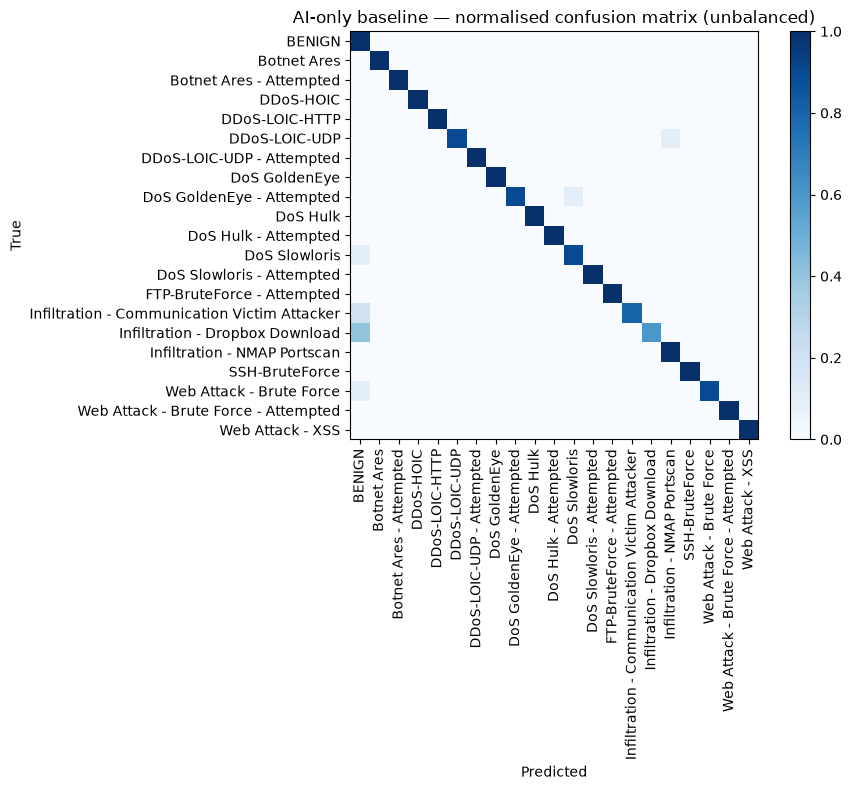

In [10]:
cm  = confusion_matrix(y_te, baseline.predict(X_te_s))
cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(CLASS_NAMES))); ax.set_xticklabels(CLASS_NAMES, rotation=90)
ax.set_yticks(range(len(CLASS_NAMES))); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"AI-only baseline — normalised confusion matrix ({SAMPLING_PROFILE})")
plt.colorbar(im); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig1_confusion_baseline.png"), dpi=150)
plt.show()

## 8. Probability calibration

Gradient-boosted models produce systematically distorted probability estimates, so a predicted
probability of 0.9 does not necessarily correspond to a 90% chance of correctness. Because the
decision gate operates directly on these values, isotonic calibration is fitted on the
validation partition and treated as part of the pipeline rather than an optional refinement.

`CalibratedClassifierCV(cv="prefit")` was removed in scikit-learn 1.8; the cell uses
`FrozenEstimator` where available and falls back automatically otherwise.

Mean confidence  raw 0.9997 -> calibrated 0.9998


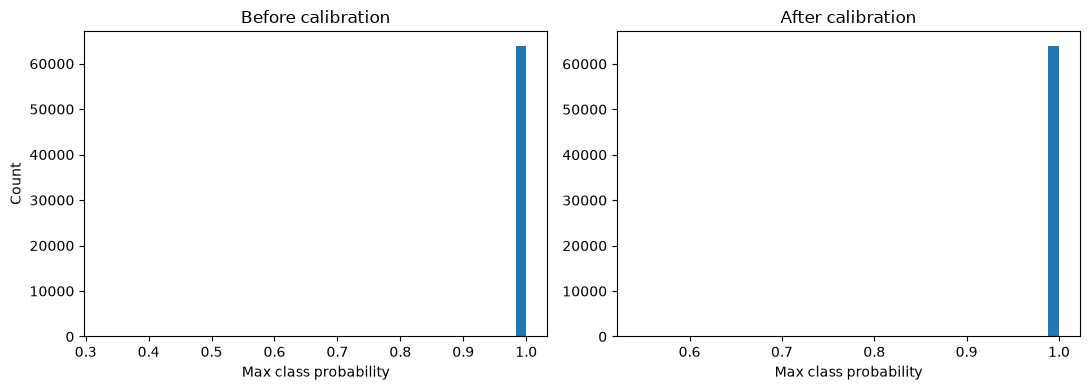

In [11]:
calibrated = (CalibratedClassifierCV(FrozenEstimator(baseline), method="isotonic")
              if HAS_FROZEN else
              CalibratedClassifierCV(baseline, method="isotonic", cv="prefit"))
calibrated.fit(X_val_s, y_val)
joblib.dump(calibrated, os.path.join(OUTPUT_DIR, "calibrated_model.pkl"))

raw_conf = baseline.predict_proba(X_val_s).max(1)
cal_conf = calibrated.predict_proba(X_val_s).max(1)
print(f"Mean confidence  raw {raw_conf.mean():.4f} -> calibrated {cal_conf.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, c, t in [(axes[0], raw_conf, "Before calibration"),
                 (axes[1], cal_conf, "After calibration")]:
    ax.hist(c, bins=40); ax.set_title(t); ax.set_xlabel("Max class probability")
axes[0].set_ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig2_calibration.png"), dpi=150); plt.show()

## 9. SHAP explanations and the concentration metric

SHAP serves two roles. Global mean absolute attribution identifies which features drive the
model overall. Per-prediction *concentration* — the share of total absolute attribution held by
the single highest-ranked feature — operationalises what it means for a prediction to be weakly
explained: if attribution is spread thinly across many features, no identifiable reason exists
for the classification, and the prediction is escalated even when confidence is high.

Explanation is therefore not solely an interface presented to the analyst but a signal within
the routing mechanism.

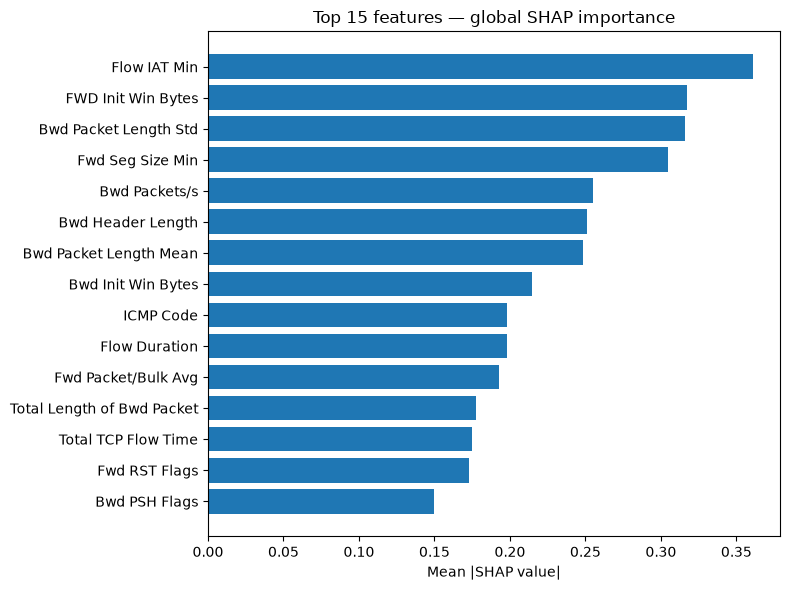

Top 5: ['Flow IAT Min', 'FWD Init Win Bytes', 'Bwd Packet Length Std', 'Fwd Seg Size Min', 'Bwd Packets/s']


In [12]:
explainer = shap.TreeExplainer(baseline)

n_glob = min(2000, len(X_val_s))
gidx = RNG.choice(len(X_val_s), size=n_glob, replace=False)
sv_glob = explainer.shap_values(X_val_s[gidx])

imp = (np.abs(sv_glob).mean(axis=(0, 2)) if np.ndim(sv_glob) == 3
       else np.abs(sv_glob).mean(0))
top = np.argsort(imp)[::-1][:15]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([feature_cols[i] for i in top][::-1], imp[top][::-1])
ax.set_xlabel("Mean |SHAP value|"); ax.set_title("Top 15 features — global SHAP importance")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig3_shap_global.png"), dpi=150); plt.show()
print("Top 5:", [feature_cols[i] for i in top[:5]])


def concentration(shap_vals, preds, positions):
    """Share of total |SHAP| held by the top feature. Low values = weakly explained."""
    out = np.zeros(len(positions))
    for k, i in enumerate(positions):
        row = shap_vals[i, :, preds[i]] if np.ndim(shap_vals) == 3 else shap_vals[i]
        a = np.abs(row); s = a.sum()
        out[k] = 0.0 if s == 0 else a.max() / s
    return out

## 10. Routing threshold — analyst capacity

The gate routes the least-confident `ROUTE_BUDGET` share of predictions rather than applying a
fixed absolute threshold. An absolute threshold proved unworkable: at 0.70, only 4 of 71,716
predictions were routed, because the confidence distribution is concentrated near unity.

A budget formulation is also closer to operational practice. A security operations centre has
fixed analyst capacity, so the practical question is not which predictions fall below an
arbitrary value but which fixed-size subset most merits review.

The sweep below reports, for a range of budgets, the residual error rate among predictions that
would be accepted automatically. This quantifies the trade-off between analyst workload and
undetected error.

 budget  n_routed  error_among_accepted_%  error_among_routed_%
   0.01       641                0.001577              2.184087
   0.02      1281                0.000000              1.170960
   0.05      3203                0.000000              0.468311
   0.10      6406                0.000000              0.234155
   0.15      9610                0.000000              0.156087
   0.20     12813                0.000000              0.117069
   0.30     19219                0.000000              0.078048


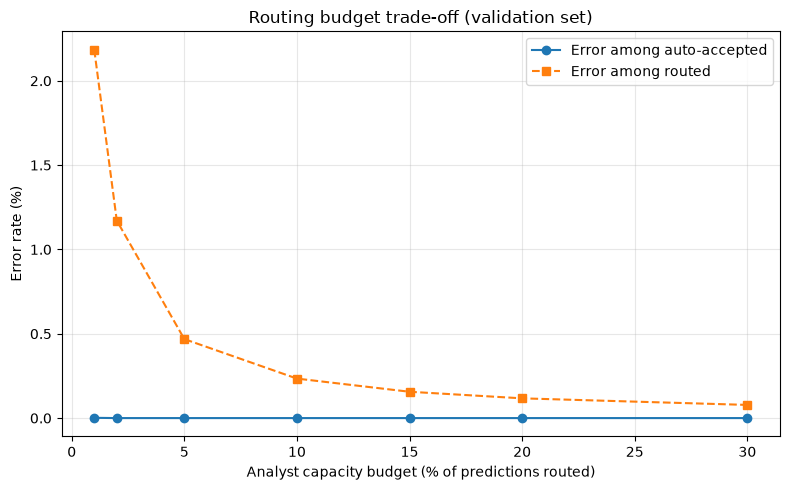

In [13]:
val_proba = calibrated.predict_proba(X_val_s)
val_pred_all, val_conf_all = val_proba.argmax(1), val_proba.max(1)

rows = []
for budget in [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30]:
    k = max(1, int(round(len(val_conf_all) * budget)))
    routed_mask = np.zeros(len(val_conf_all), dtype=bool)
    routed_mask[np.argsort(val_conf_all)[:k]] = True
    kept = ~routed_mask
    err  = (val_pred_all[kept] != y_val[kept]).mean()
    err_routed = (val_pred_all[routed_mask] != y_val[routed_mask]).mean()
    rows.append({"budget": budget, "n_routed": int(k),
                 "error_among_accepted_%": err * 100,
                 "error_among_routed_%":   err_routed * 100})

SWEEP = pd.DataFrame(rows)
print(SWEEP.to_string(index=False))
SWEEP.to_csv(os.path.join(OUTPUT_DIR, "threshold_sweep.csv"), index=False)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(SWEEP.budget * 100, SWEEP["error_among_accepted_%"], marker="o",
         label="Error among auto-accepted")
ax1.plot(SWEEP.budget * 100, SWEEP["error_among_routed_%"], marker="s", linestyle="--",
         label="Error among routed")
ax1.set_xlabel("Analyst capacity budget (% of predictions routed)")
ax1.set_ylabel("Error rate (%)")
ax1.set_title("Routing budget trade-off (validation set)")
ax1.legend(); ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig4_budget_tradeoff.png"), dpi=150); plt.show()

## 11. The decision gate — objective O2

A prediction is accepted automatically only if it satisfies both criteria: confidence outside
the least-confident `ROUTE_BUDGET` share, and attribution concentrated on at least one
identifiable feature. Failing either routes it for review.

SHAP is computed only for predictions already flagged as low-confidence; computing attributions
for every record would be prohibitively expensive and unnecessary for predictions the system is
willing to trust.

In [14]:
def decision_gate(model, expl, X_scaled, budget=ROUTE_BUDGET,
                  conc_thr=CONCENTRATION_THRESHOLD, shap_cap=20000):
    proba = model.predict_proba(X_scaled)
    preds, conf = proba.argmax(1), proba.max(1)

    k = max(1, int(round(len(conf) * budget)))
    low_conf = np.zeros(len(conf), dtype=bool)
    low_conf[np.argsort(conf)[:k]] = True

    weak_expl = np.zeros(len(X_scaled), dtype=bool)
    idx = np.where(low_conf)[0]
    if len(idx):
        batch = idx[:shap_cap]
        sv = expl.shap_values(X_scaled[batch])
        weak_expl[batch] = concentration(sv, preds[batch],
                                         np.arange(len(batch))) < conc_thr

    routed = low_conf | weak_expl
    return preds, conf, routed, low_conf, weak_expl


val_pred, val_conf, val_routed, val_lc, val_we = decision_gate(
    calibrated, explainer, X_val_s)

print(f"Routed to analyst: {val_routed.sum():,} / {len(val_routed):,} "
      f"({val_routed.mean()*100:.2f}%)")
print(f"  low confidence   : {val_lc.sum():,}")
print(f"  weak explanation : {val_we.sum():,}")
print(f"Accuracy among auto-accepted: "
      f"{(val_pred[~val_routed] == y_val[~val_routed]).mean():.4f}")
print(f"Accuracy among routed       : "
      f"{(val_pred[val_routed] == y_val[val_routed]).mean():.4f}")

Routed to analyst: 3,203 / 64,064 (5.00%)
  low confidence   : 3,203
  weak explanation : 1,384
Accuracy among auto-accepted: 1.0000
Accuracy among routed       : 0.9953


## 12. Simulated analyst — objective O2

Obtaining human judgements at the scale of a validation partition is not feasible within this
study, and collecting them as analysed data would require ethical approval for human-subject
research. Analyst decisions are therefore simulated using ground-truth labels as a proxy, on
the premise that an analyst inspecting a flow can establish its true nature where the recorded
label may be wrong.

An error rate is applied so the analyst is not treated as an infallible oracle; when an error
occurs the analyst accepts the model's original prediction regardless of correctness.

In [15]:
def simulated_analyst(
    y_true,
    y_pred,
    benign_enc,
    error_rate,
    rng,
    model="realistic",
    n_classes=None
):
    """
    Simulate analyst adjudication.

    realistic:
        The analyst can miss an existing model error but does not
        alter predictions that were already correct.

    pessimistic:
        The analyst can also corrupt a prediction that was already
        correct by assigning an incorrect class.
    """
    if n_classes is None:
        raise ValueError("n_classes must be provided")

    decisions = np.empty(len(y_true), dtype=object)
    final = y_pred.copy()

    for i, (t, p) in enumerate(zip(y_true, y_pred)):

        if t == p:
            if model == "pessimistic" and rng.random() < error_rate:
                alternatives = np.arange(n_classes)
                alternatives = alternatives[alternatives != t]

                final[i] = rng.choice(alternatives)
                decisions[i] = "error"
            else:
                final[i] = p
                decisions[i] = "approve"

            continue

        # The model prediction is incorrect
        if rng.random() < error_rate:
            final[i] = p
            decisions[i] = "error"
            continue

        if t == benign_enc:
            final[i] = benign_enc
            decisions[i] = "reject"
        else:
            final[i] = t
            decisions[i] = "correct"

    return decisions, final

routed_idx = np.where(val_routed)[0]
decisions, corrected = simulated_analyst(
    y_val[routed_idx], val_pred[routed_idx], BENIGN_ENC,
    ANALYST_ERROR_RATE, np.random.default_rng(SEED), model=ANALYST_ERROR_MODEL ,
    n_classes=len(CLASS_NAMES))

u, c = np.unique(decisions, return_counts=True)
print(f"Analyst reviewed {len(routed_idx):,} predictions:")
for k, v in zip(u, c):
    print(f"  {k:8s} {v:6,}  ({v/len(decisions)*100:5.1f}%)")

successful_corrections = int(
    ((decisions == "correct") | (decisions == "reject")).sum()
)

introduced_errors = int(np.sum(
    (y_val[routed_idx] == val_pred[routed_idx]) &
    (corrected != y_val[routed_idx])
))

missed_model_errors = int(np.sum(
    (y_val[routed_idx] != val_pred[routed_idx]) &
    (corrected != y_val[routed_idx])
))

# Any final label that differs from the original model prediction
n_changed = int(np.sum(
    corrected != val_pred[routed_idx]
))

total_incorrect_after_review = int(np.sum(
    corrected != y_val[routed_idx]
))

print(f"\nSuccessful corrections or rejections: "
      f"{successful_corrections:,}")

print(f"Incorrect labels introduced on originally correct cases: "
      f"{introduced_errors:,}")

print(f"Existing model errors not corrected: "
      f"{missed_model_errors:,}")

print(f"Total labels changed by analyst: "
      f"{n_changed:,}")

print(f"Total incorrect reviewed labels after adjudication: "
      f"{total_incorrect_after_review:,}")

Analyst reviewed 3,203 predictions:
  approve   2,861  ( 89.3%)
  correct       9  (  0.3%)
  error       327  ( 10.2%)
  reject        6  (  0.2%)

Successful corrections or rejections: 15
Incorrect labels introduced on originally correct cases: 327
Existing model errors not corrected: 0
Total labels changed by analyst: 342
Total incorrect reviewed labels after adjudication: 327


## 13. Retraining with analyst feedback — objective O2

Records adjudicated by the analyst, carrying their post-review labels, are appended to the
training partition and the classifier is retrained from scratch with class weights recomputed.
Gradient-boosted ensembles admit no incremental update, so the entire model is rebuilt on all
records at once across all classes — there is no per-class retraining.

This closes the loop that the base paper leaves open: prior work ranks flows for analyst
attention but does not incorporate the outcome of that attention into the model.

In [16]:
X_hitl = np.vstack([X_tr_s, X_val_s[routed_idx]])
y_hitl = np.concatenate([y_tr, corrected])
w_hitl = compute_sample_weight(class_weight="balanced", y=y_hitl)
print(f"Training set: {len(y_tr):,} -> {len(y_hitl):,} "
      f"(+{len(routed_idx):,} analyst-validated)")

hitl_model = make_model()
hitl_model.fit(X_hitl, y_hitl, sample_weight=w_hitl, verbose=False)
hitl_model.save_model(os.path.join(OUTPUT_DIR, "hitl_xgb.json"))
print("HITL model trained.")

Training set: 192,192 -> 195,395 (+3,203 analyst-validated)
HITL model trained.


## 14. AI-only versus HITL — objective O3

Both configurations are evaluated on the same held-out test partition, which neither has
seen.

In [17]:
hitl_test = evaluate(hitl_model, X_te_s, y_te, "HITL — TEST")

COMPARISON = pd.DataFrame({"AI-only": baseline_test, "HITL": hitl_test}).T[
    ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted", "mcc"]]
COMPARISON.loc["Difference"] = COMPARISON.loc["HITL"] - COMPARISON.loc["AI-only"]
print("\n", COMPARISON.round(4).to_string())
COMPARISON.to_csv(os.path.join(OUTPUT_DIR, "comparison_ai_vs_hitl.csv"))

--- HITL — TEST ---
Accuracy 0.9972 | Macro-F1 0.7920 | Weighted-F1 0.9976 | MCC 0.9776

                                              precision    recall  f1-score   support

                                      BENIGN       1.00      1.00      1.00     60067
                                 Botnet Ares       0.95      1.00      0.97       157
                     Botnet Ares - Attempted       0.67      1.00      0.80        10
                                   DDoS-HOIC       0.99      1.00      1.00      1190
                              DDoS-LOIC-HTTP       0.98      1.00      0.99       318
                               DDoS-LOIC-UDP       0.38      1.00      0.56        10
                   DDoS-LOIC-UDP - Attempted       0.71      1.00      0.83        10
                               DoS GoldenEye       0.83      1.00      0.91        25
                   DoS GoldenEye - Attempted       0.56      0.90      0.69        10
                                    DoS Hulk      

## 15. Cross-validation — objective O4

Cross-validated scores are reported for both configurations.

**These are descriptive, not inferential.** The two configurations are trained on datasets of
different size and composition, so their folds are not matched observations and a paired
significance test between them would not be valid. Controlled statistical comparison is
performed in Section 19, where both configurations see identical data and differ only in the
presence of the human validation step.

In [18]:
def cv_scores(X_, y_, label):
    skf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=SEED)
    out = []
    for i, (tr, te) in enumerate(skf.split(X_, y_)):
        m = make_model()
        m.fit(X_[tr], y_[tr],
              sample_weight=compute_sample_weight("balanced", y_[tr]), verbose=False)
        _, _, f1, _ = precision_recall_fscore_support(y_[te], m.predict(X_[te]),
                                                      average="macro", zero_division=0)
        out.append(f1); print(f"  {label} fold {i+1}/{N_CV_FOLDS}: macro-F1 {f1:.4f}")
    return np.array(out)

print("AI-only:"); ai_scores   = cv_scores(X_tr_s, y_tr, "AI-only")
print("HITL:");    hitl_scores = cv_scores(X_hitl, y_hitl, "HITL")

print(f"\nAI-only macro-F1: {ai_scores.mean():.4f} +/- {ai_scores.std():.4f}")
print(f"HITL    macro-F1: {hitl_scores.mean():.4f} +/- {hitl_scores.std():.4f}")
print("\nNote: descriptive only — the folds are not matched, so no paired test is reported "
      "here. See Section 19.")

AI-only:
  AI-only fold 1/5: macro-F1 0.9367
  AI-only fold 2/5: macro-F1 0.9463
  AI-only fold 3/5: macro-F1 0.9598
  AI-only fold 4/5: macro-F1 0.9364
  AI-only fold 5/5: macro-F1 0.9607
HITL:
  HITL fold 1/5: macro-F1 0.7481
  HITL fold 2/5: macro-F1 0.7302
  HITL fold 3/5: macro-F1 0.7083
  HITL fold 4/5: macro-F1 0.7442
  HITL fold 5/5: macro-F1 0.7135

AI-only macro-F1: 0.9480 +/- 0.0106
HITL    macro-F1: 0.7288 +/- 0.0159

Note: descriptive only — the folds are not matched, so no paired test is reported here. See Section 19.


## 16. Explanation stability across folds

Because results derive from a sample, the stability of feature attributions under resampling
requires verification: if a different sample would yield different important features, the
routing behaviour that depends on explanation concentration would be contingent on which
records happened to be drawn.

A model is trained on each fold, mean absolute SHAP importance is computed on the held-out
fold, and rankings are compared pairwise using Spearman correlation, Kendall's tau, and top-k
Jaccard overlap. Per-feature rank standard deviation distinguishes robustly important features
from those whose position varies with the sample.

In [19]:
def fold_shap_importances(X_, y_, n_folds=N_CV_FOLDS, sample_for_shap=1500, seed=SEED):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    rng_local = np.random.default_rng(seed)
    imps = []
    print("Computing SHAP importance per fold (this takes a few minutes)...")
    for i, (tr, te) in enumerate(skf.split(X_, y_)):
        m = make_model()
        m.fit(X_[tr], y_[tr],
              sample_weight=compute_sample_weight("balanced", y_[tr]), verbose=False)
        e = shap.TreeExplainer(m)
        k = min(sample_for_shap, len(te))
        idx = rng_local.choice(te, size=k, replace=False)
        sv = e.shap_values(X_[idx])
        imp = (np.abs(sv).mean(axis=(0, 2)) if np.ndim(sv) == 3 else np.abs(sv).mean(0))
        imps.append(imp)
        print(f"  fold {i+1}/{n_folds}: SHAP computed on {k} samples")
    return imps


def explanation_stability(importances, feature_names, top_k=10):
    F = len(importances); sp, kt, jac = [], [], []
    for a in range(F):
        for b in range(a + 1, F):
            ia, ib = importances[a], importances[b]
            sp.append(spearmanr(ia, ib).statistic)
            kt.append(kendalltau(ia, ib).statistic)
            ta = set(np.argsort(ia)[::-1][:top_k]); tb = set(np.argsort(ib)[::-1][:top_k])
            jac.append(len(ta & tb) / len(ta | tb))
    mean_imp = np.mean(importances, axis=0)
    ranks = np.array([stats.rankdata(-f) for f in importances])
    order = np.argsort(mean_imp)[::-1][:top_k]
    tbl = pd.DataFrame({
        "feature":       [feature_names[i] for i in order],
        "mean_abs_shap": mean_imp[order].round(6),
        "mean_rank":     ranks[:, order].mean(0).round(2),
        "rank_std":      ranks[:, order].std(0).round(2)})
    return {"spearman_mean": float(np.mean(sp)), "spearman_min": float(np.min(sp)),
            "kendall_mean": float(np.mean(kt)),
            f"jaccard_top{top_k}_mean": float(np.mean(jac))}, tbl


fold_imps = fold_shap_importances(X_tr_s, y_tr)
STABILITY, STABILITY_TABLE = explanation_stability(fold_imps, feature_cols)

print("\n--- Explanation stability across folds ---")
for k, v in STABILITY.items():
    print(f"  {k:24s} {v:.4f}")
print("\nTop features (rank_std shows movement between folds):")
print(STABILITY_TABLE.to_string(index=False))
STABILITY_TABLE.to_csv(os.path.join(OUTPUT_DIR, "shap_stability.csv"), index=False)

Computing SHAP importance per fold (this takes a few minutes)...
  fold 1/5: SHAP computed on 1500 samples
  fold 2/5: SHAP computed on 1500 samples
  fold 3/5: SHAP computed on 1500 samples
  fold 4/5: SHAP computed on 1500 samples
  fold 5/5: SHAP computed on 1500 samples

--- Explanation stability across folds ---
  spearman_mean            0.9523
  spearman_min             0.9349
  kendall_mean             0.8407
  jaccard_top10_mean       0.5678

Top features (rank_std shows movement between folds):
               feature  mean_abs_shap  mean_rank  rank_std
          Flow IAT Min       0.345988        1.0      0.00
      Fwd Seg Size Min       0.300278        3.2      1.47
 Bwd Packet Length Std       0.293643        2.8      0.75
    FWD Init Win Bytes       0.289039        3.8      1.17
     Bwd Header Length       0.272896        4.6      0.49
         Bwd Packets/s       0.206795       10.4      5.75
Bwd Packet Length Mean       0.203440       10.8      4.75
    Bwd Init Win B

## 17. Augmentation control

The human-validated configuration is trained on more records than the baseline, since routed
records are appended to the training pool. Any observed difference could therefore arise from
the additional data rather than from the analyst's contribution.

A control configuration is evaluated in which the same routed records are appended carrying the
**model's own predicted labels**, with no analyst involvement. Comparing the three
configurations isolates the contribution attributable to human validation.

If the control matches or exceeds the human-validated configuration, the observed gain is
data augmentation rather than human validation — an outcome worth reporting explicitly.

In [20]:
X_ctrl = np.vstack([X_tr_s, X_val_s[routed_idx]])
y_ctrl = np.concatenate([y_tr, val_pred[routed_idx]])   # model's own labels, no human
ctrl = make_model()
ctrl.fit(X_ctrl, y_ctrl,
         sample_weight=compute_sample_weight("balanced", y_ctrl), verbose=False)
_, _, ctrl_f1, _ = precision_recall_fscore_support(
    y_te, ctrl.predict(X_te_s), average="macro", zero_division=0)

print(f"AI-only                    : {baseline_test['f1_macro']:.4f}")
print(f"+ routed rows, no human    : {ctrl_f1:.4f}")
print(f"+ routed rows, with human  : {hitl_test['f1_macro']:.4f}")

gain_total = hitl_test["f1_macro"] - baseline_test["f1_macro"]
gain_aug   = ctrl_f1 - baseline_test["f1_macro"]
gain_human = hitl_test["f1_macro"] - ctrl_f1
print(f"\nTotal change      : {gain_total:+.4f}")
print(f"  from added data : {gain_aug:+.4f}")
print(f"  from the human  : {gain_human:+.4f}")

CONTROL = {"ai_only_f1_macro": float(baseline_test["f1_macro"]),
           "augmented_no_human_f1_macro": float(ctrl_f1),
           "augmented_with_human_f1_macro": float(hitl_test["f1_macro"]),
           "gain_from_augmentation": float(gain_aug),
           "gain_from_human": float(gain_human),
           "n_routed": int(len(routed_idx)),
           "labels_changed_by_analyst": int(n_changed),
           "analyst_errors": int((decisions == "error").sum())}
with open(os.path.join(OUTPUT_DIR, "control_augmentation.json"), "w") as f:
    json.dump(CONTROL, f, indent=2)

AI-only                    : 0.9319
+ routed rows, no human    : 0.9389
+ routed rows, with human  : 0.7920

Total change      : -0.1399
  from added data : +0.0070
  from the human  : -0.1469


## 18. Label-noise robustness

Sections 14 and 17 establish whether human validation helps under the conditions the benchmark
presents. They do not establish the conditions under which it helps. This section addresses
that by degrading label quality in a controlled manner.

Label noise is used as the stressor because it is documented for this dataset rather than
invented: the corrected release exists precisely because the original contained approximately
7.5% labelling error. Two noise models are evaluated: **symmetric**, where labels are
reassigned to a random alternative class, and **attack-to-benign**, where attack records are
relabelled as benign — the operationally consequential direction.

Noise is applied to training and validation labels only. The test partition retains its
original labels, so every configuration is scored against unmodified ground truth. The
simulated analyst also sees unmodified labels for routed records, reflecting the premise that
human inspection recovers information the corrupted training data has lost.

In [21]:
def inject_label_noise(y_clean, rate, mode, rng, benign_enc, n_classes):
    y_noisy = y_clean.copy()
    if rate <= 0:
        return y_noisy, np.array([], dtype=int)

    if mode == "attack_to_benign":
        # Rate is a proportion of ATTACK records, not of all records. Under the
        # unbalanced profile attacks are ~6% of the data, so applying the rate to
        # the full dataset would relabel every attack and leave a single class.
        cand = np.where(y_clean != benign_enc)[0]
        k = min(len(cand) - 1, int(round(len(cand) * rate)))   # keep at least one attack
        k = max(k, 0)
        if k > 0:
            idx = rng.choice(cand, size=k, replace=False)
            y_noisy[idx] = benign_enc
        else:
            idx = np.array([], dtype=int)
    else:
        idx = rng.choice(len(y_clean), size=int(round(len(y_clean) * rate)),
                         replace=False)
        for i in idx:
            alt = [c for c in range(n_classes) if c != y_clean[i]]
            y_noisy[i] = rng.choice(alt)

    return y_noisy, idx


def run_noise_condition(noise_rate, mode, seed=SEED, analyst_model="realistic", budget=ROUTE_BUDGET,
                        conc_thr=CONCENTRATION_THRESHOLD, eps=ANALYST_ERROR_RATE,
                        shap_cap=2000):
    """Train AI-only and HITL under one noise condition; score both on the clean test set."""
    rng = np.random.default_rng(seed)
    n_classes = len(CLASS_NAMES)

    y_tr_n,  _ = inject_label_noise(y_tr,  noise_rate, mode, rng, BENIGN_ENC, n_classes)
    y_val_n, _ = inject_label_noise(y_val, noise_rate, mode, rng, BENIGN_ENC, n_classes)
    if len(np.unique(y_tr_n)) < 2 or len(np.unique(y_val_n)) < 2:
        return {"noise_rate": noise_rate, "mode": mode, "routed": 0, "routed_pct": np.nan,
                "ai_f1": np.nan, "hitl_f1": np.nan, "delta_f1": np.nan,
                "skipped": "insufficient classes after noise injection"}

    ai = make_model()
    ai.fit(X_tr_s, y_tr_n,
           sample_weight=compute_sample_weight("balanced", y_tr_n), verbose=False)
    _, _, ai_f1, _ = precision_recall_fscore_support(
        y_te, ai.predict(X_te_s), average="macro", zero_division=0)

    try:
        cal = (CalibratedClassifierCV(FrozenEstimator(ai), method="isotonic") if HAS_FROZEN
               else CalibratedClassifierCV(ai, method="isotonic", cv="prefit"))
        cal.fit(X_val_s, y_val_n)
    except Exception:
        cal = ai

    proba = cal.predict_proba(X_val_s)
    preds, conf = proba.argmax(1), proba.max(1)
    k = max(1, int(round(len(conf) * budget)))
    low_conf = np.zeros(len(conf), dtype=bool)
    low_conf[np.argsort(conf)[:k]] = True

    weak = np.zeros(len(preds), dtype=bool)
    idx = np.where(low_conf)[0]
    if len(idx):
        b = idx[:shap_cap]
        sv = shap.TreeExplainer(ai).shap_values(X_val_s[b])
        weak[b] = concentration(sv, preds[b], np.arange(len(b))) < conc_thr
    routed = low_conf | weak
    ridx = np.where(routed)[0]

    if len(ridx):
        _, corr = simulated_analyst(
    y_val[ridx],
    preds[ridx],
    BENIGN_ENC,
    eps,
    rng,
    model=analyst_model,
    n_classes=len(CLASS_NAMES)
)
        X_h = np.vstack([X_tr_s, X_val_s[ridx]]); y_h = np.concatenate([y_tr_n, corr])
    else:
        X_h, y_h = X_tr_s, y_tr_n

    hl = make_model()
    hl.fit(X_h, y_h, sample_weight=compute_sample_weight("balanced", y_h), verbose=False)
    _, _, hitl_f1, _ = precision_recall_fscore_support(
        y_te, hl.predict(X_te_s), average="macro", zero_division=0)

    return {"noise_rate": noise_rate, "mode": mode, "analyst_model": analyst_model,
            "routed": int(routed.sum()), "routed_pct": float(routed.mean() * 100),
            "ai_f1": float(ai_f1), "hitl_f1": float(hitl_f1),
            "delta_f1": float(hitl_f1 - ai_f1)}

## 19. Multi-seed replication and significance testing

Each condition is repeated across several noise realisations so reported differences can be
distinguished from run-to-run variance. The classifier's random state is held fixed; only the
noise draw and the analyst's error draw vary, isolating the effect of *which* labels are
corrupted.

This is the controlled comparison referred to in Section 15: both configurations see identical
data under identical noise, differing only in the human validation step, so a paired test is
valid here.

With five paired samples the Wilcoxon signed-rank test has a minimum attainable p-value of
0.0625 and therefore cannot reach conventional significance; the paired t-test is reported
alongside it, and the count of seeds in which HITL outperformed the baseline is given as a
directly interpretable summary.

**This is the slowest section** — it trains two models per seed per condition.

In [22]:
N_SEEDS = 5
SEEDS = [SEED + i for i in range(N_SEEDS)]
REPLICATE_RATES = [0.0, 0.075, 0.20, 0.40]

rep_rows = []
for mode in ["symmetric", "attack_to_benign"]:
    print(f"\n--- {mode.replace('_',' ')} noise ({N_SEEDS} seeds per condition) ---")
    print(f"{'noise':>7} {'routed%':>9} {'AI F1':>18} {'HITL F1':>18} {'delta':>18}")
    for rate in REPLICATE_RATES:
        runs = [run_noise_condition(rate, mode, seed=s, analyst_model=NOISE_ANALYST_MODEL) for s in SEEDS]
        ai = np.array([r["ai_f1"] for r in runs])
        hl = np.array([r["hitl_f1"] for r in runs])
        rt = np.array([r["routed_pct"] for r in runs])
        d  = hl - ai
        t_p = stats.ttest_rel(ai, hl).pvalue if N_SEEDS > 1 else np.nan
        try:
            w_p = stats.wilcoxon(ai, hl).pvalue if N_SEEDS > 2 else np.nan
        except ValueError:
            w_p = np.nan
        rep_rows.append({
            "mode": mode, "noise_rate": rate, "n_seeds": N_SEEDS,
            "routed_pct_mean": rt.mean(),
            "ai_f1_mean": ai.mean(), "ai_f1_std": ai.std(ddof=1),
            "hitl_f1_mean": hl.mean(), "hitl_f1_std": hl.std(ddof=1),
            "delta_mean": d.mean(), "delta_std": d.std(ddof=1),
            "ttest_p": t_p, "wilcoxon_p": w_p,
            "seeds_hitl_wins": int((d > 0).sum())})
        print(f"{rate:>6.1%} {rt.mean():>8.2f}% "
              f"{ai.mean():>9.4f}±{ai.std(ddof=1):<7.4f} "
              f"{hl.mean():>9.4f}±{hl.std(ddof=1):<7.4f} "
              f"{d.mean():>+9.4f}±{d.std(ddof=1):<7.4f}")

NOISE_TABLE = pd.DataFrame(rep_rows)
NOISE_TABLE.to_csv(os.path.join(OUTPUT_DIR, "noise_multiseed.csv"), index=False)

print("\nConditions significant at p < 0.05 (paired t-test):")
sig = NOISE_TABLE[NOISE_TABLE.ttest_p < 0.05]
if len(sig):
    for _, r in sig.iterrows():
        print(f"  {r['mode'].replace('_',' '):18s} {r.noise_rate:>5.1%}: "
              f"delta = {r.delta_mean:+.4f} ± {r.delta_std:.4f}, p = {r.ttest_p:.4f}, "
              f"HITL won {r.seeds_hitl_wins}/{int(r.n_seeds)} seeds")
else:
    print("  none")


--- symmetric noise (5 seeds per condition) ---
  noise   routed%              AI F1            HITL F1              delta
  0.0%     5.00%    0.9319±0.0000     0.7877±0.0132    -0.1442±0.0132 
  7.5%     5.00%    0.1630±0.0009     0.1641±0.0016    +0.0011±0.0011 
 20.0%     5.00%    0.1255±0.0003     0.1264±0.0008    +0.0009±0.0010 
 40.0%     5.00%    0.1074±0.0008     0.1100±0.0023    +0.0026±0.0016 

--- attack to benign noise (5 seeds per condition) ---
  noise   routed%              AI F1            HITL F1              delta
  0.0%     5.00%    0.9319±0.0000     0.7877±0.0132    -0.1442±0.0132 
  7.5%     5.00%    0.9311±0.0011     0.9314±0.0051    +0.0003±0.0046 
 20.0%     5.00%    0.9282±0.0035     0.9203±0.0070    -0.0079±0.0098 
 40.0%     5.00%    0.9162±0.0029     0.9144±0.0070    -0.0018±0.0096 

Conditions significant at p < 0.05 (paired t-test):
  symmetric           0.0%: delta = -0.1442 ± 0.0132, p = 0.0000, HITL won 0/5 seeds
  symmetric          40.0%: delta = +0.

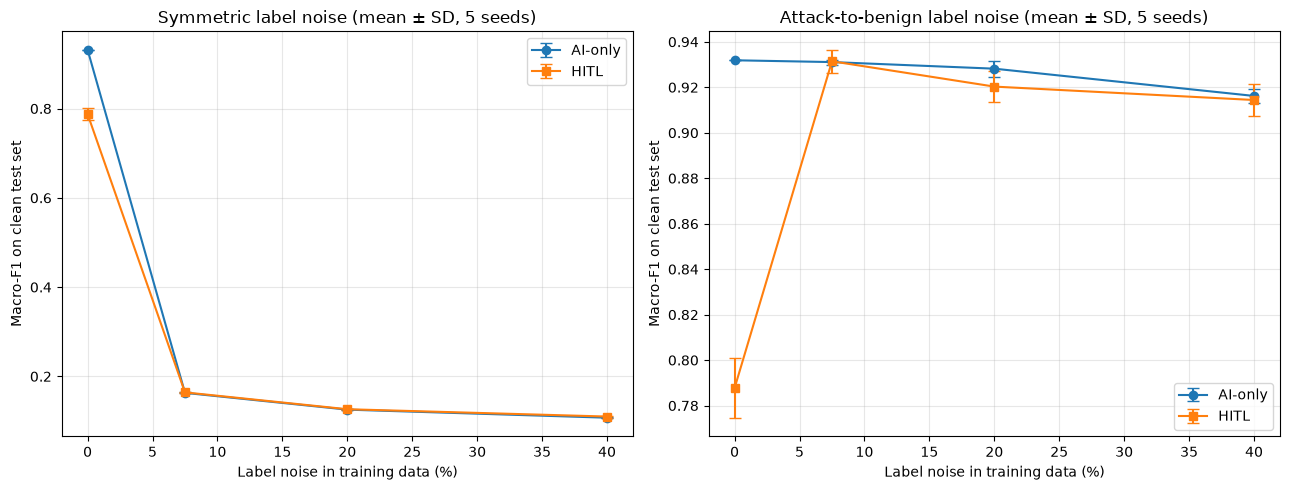

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mode, title in [(axes[0], "symmetric", "Symmetric label noise"),
                        (axes[1], "attack_to_benign", "Attack-to-benign label noise")]:
    sub = NOISE_TABLE[NOISE_TABLE["mode"] == mode]
    ax.errorbar(sub.noise_rate*100, sub.ai_f1_mean, yerr=sub.ai_f1_std,
                marker="o", capsize=4, label="AI-only")
    ax.errorbar(sub.noise_rate*100, sub.hitl_f1_mean, yerr=sub.hitl_f1_std,
                marker="s", capsize=4, label="HITL")
    ax.set_xlabel("Label noise in training data (%)")
    ax.set_ylabel("Macro-F1 on clean test set")
    ax.set_title(f"{title} (mean ± SD, {N_SEEDS} seeds)")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig5_noise_multiseed.png"), dpi=150); plt.show()

In [24]:
# Paired effect size (Cohen's d_z) from the saved multi-seed results
NOISE_TABLE = pd.read_csv(os.path.join(OUTPUT_DIR, "noise_multiseed.csv"))
NOISE_TABLE["cohens_d"] = (NOISE_TABLE.delta_mean / NOISE_TABLE.delta_std).round(2)

print(NOISE_TABLE[["mode", "noise_rate", "delta_mean", "delta_std",
                   "cohens_d", "ttest_p", "seeds_hitl_wins"]].to_string(index=False))
NOISE_TABLE.to_csv(os.path.join(OUTPUT_DIR, "noise_multiseed.csv"), index=False)

            mode  noise_rate  delta_mean  delta_std  cohens_d  ttest_p  seeds_hitl_wins
       symmetric       0.000   -0.144172   0.013199    -10.92 0.000017                0
       symmetric       0.075    0.001094   0.001057      1.03 0.081665                4
       symmetric       0.200    0.000908   0.001024      0.89 0.118530                5
       symmetric       0.400    0.002588   0.001568      1.65 0.020990                5
attack_to_benign       0.000   -0.144172   0.013199    -10.92 0.000017                0
attack_to_benign       0.075    0.000350   0.004621      0.08 0.873792                4
attack_to_benign       0.200   -0.007886   0.009771     -0.81 0.145429                1
attack_to_benign       0.400   -0.001788   0.009642     -0.19 0.699673                2


## 20. Saving results

Every reported figure is written to the run directory alongside the configuration that
produced it, so results can be attributed unambiguously to the settings that generated them.
A markdown table is also written for direct inclusion in the thesis.

In [25]:
RESULTS = {
    "run_name": RUN_NAME,
    "generated": datetime.now().isoformat(timespec="seconds"),
    "config": {
        "sampling_profile": SAMPLING_PROFILE,
        "sample_fraction": SAMPLE_FRACTION,
        "max_per_class": MAX_PER_CLASS,
        "min_per_class": MIN_PER_CLASS,
        "min_class_size": MIN_CLASS_SIZE,
        "attempted_policy": ATTEMPTED_POLICY,
        "route_budget": ROUTE_BUDGET,
        "concentration_threshold": CONCENTRATION_THRESHOLD,
        "analyst_error_rate": ANALYST_ERROR_RATE,
        "cv_folds": N_CV_FOLDS, "seed": SEED,
        "n_records": int(len(raw)), "n_features": len(feature_cols),
        "n_classes": len(CLASS_NAMES), "classes": CLASS_NAMES,
        "excluded_classes": {str(k): int(v) for k, v in EXCLUDED_CLASSES.items()},
    },
    "representativeness": {"chi2": None if np.isnan(CHI2) else float(CHI2),
                           "chi2_p": None if np.isnan(CHI2_P) else float(CHI2_P),
                           "kl_divergence": float(KL_DIV),
                           "max_deviation_pp": float(REP_TABLE.abs_diff_pp.max())},
    "baseline_validation": baseline_val,
    "baseline_test": baseline_test,
    "hitl_test": hitl_test,
    "decision_gate": {"routed": int(val_routed.sum()),
                      "routed_pct": float(val_routed.mean()*100),
                      "low_confidence": int(val_lc.sum()),
                      "weak_explanation": int(val_we.sum()),
                      "accuracy_auto_accepted":
                          float((val_pred[~val_routed] == y_val[~val_routed]).mean()),
                      "accuracy_routed":
                          float((val_pred[val_routed] == y_val[val_routed]).mean())},
    "analyst_decisions": {str(k): int(v) for k, v in
                          zip(*np.unique(decisions, return_counts=True))},
    "control": CONTROL,
    "cv": {"ai_only_f1": ai_scores.tolist(), "hitl_f1": hitl_scores.tolist()},
    "explanation_stability": STABILITY,
    "noise_multiseed": NOISE_TABLE.to_dict(orient="records"),
}
with open(os.path.join(OUTPUT_DIR, "results_summary.json"), "w") as f:
    json.dump(RESULTS, f, indent=2)

md_lines = [f"### Results — {SAMPLING_PROFILE} profile", "",
            "| Metric | AI-only | HITL | Difference |", "|---|---|---|---|"]
for m in ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted", "mcc"]:
    md_lines.append(f"| {m} | {baseline_test[m]:.4f} | {hitl_test[m]:.4f} | "
                    f"{hitl_test[m]-baseline_test[m]:+.4f} |")
with open(os.path.join(OUTPUT_DIR, "results_table.md"), "w") as f:
    f.write("\n".join(md_lines))

print("Saved to", os.path.abspath(OUTPUT_DIR))
for f_ in sorted(os.listdir(OUTPUT_DIR)):
    print("   ", f_)

Saved to c:\Users\seri\Desktop\MSC. AI\Thesis\Thesis Project - HITL vs AI\HITLV2\results_reproduction\run_unbalanced_pessimistic_seed42_reproduction
    baseline_xgb.json
    calibrated_model.pkl
    comparison_ai_vs_hitl.csv
    control_augmentation.json
    fig1_confusion_baseline.png
    fig2_calibration.png
    fig3_shap_global.png
    fig4_budget_tradeoff.png
    fig5_noise_multiseed.png
    hitl_xgb.json
    noise_multiseed.csv
    preprocessing.pkl
    results_summary.json
    results_table.md
    sample_representativeness.csv
    shap_stability.csv
    threshold_sweep.csv


## 21. Run log

Compares every completed run under `RESULTS_ROOT`, so balanced and unbalanced profiles can be
placed side by side without re-running anything.

In [26]:
def run_log(results_root=RESULTS_ROOT):
    rows = []
    if not os.path.isdir(results_root):
        return pd.DataFrame()
    for run in sorted(os.listdir(results_root)):
        path = os.path.join(results_root, run, "results_summary.json")
        if not os.path.exists(path):
            continue
        with open(path) as f:
            r = json.load(f)
        cfg = r.get("config", {})
        rows.append({
            "run": run,
            "profile": cfg.get("sampling_profile"),
            "records": cfg.get("n_records"),
            "classes": cfg.get("n_classes"),
            "AI_f1": round(r.get("baseline_test", {}).get("f1_macro", float("nan")), 4),
            "HITL_f1": round(r.get("hitl_test", {}).get("f1_macro", float("nan")), 4),
            "AI_acc": round(r.get("baseline_test", {}).get("accuracy", float("nan")), 4),
            "AI_mcc": round(r.get("baseline_test", {}).get("mcc", float("nan")), 4),
            "routed_%": round(r.get("decision_gate", {}).get("routed_pct", float("nan")), 2),
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df["delta_f1"] = (df.HITL_f1 - df.AI_f1).round(4)
    return df

LOG = run_log()
print(f"{len(LOG)} run(s) recorded\n")
print(LOG.to_string(index=False) if not LOG.empty else "none")

2 run(s) recorded

                                           run    profile  records  classes  AI_f1  HITL_f1  AI_acc  AI_mcc  routed_%  delta_f1
            run_unbalanced_2026-08-23_21-03-47 unbalanced   320320       21 0.9319   0.9421  0.9994  0.9953       5.0    0.0102
run_unbalanced_pessimistic_seed42_reproduction unbalanced   320320       21 0.9319   0.7920  0.9994  0.9953       5.0   -0.1399


## 22. Reloading a previous run

To restore results after closing the notebook, run Section 1 (imports) and then this cell.
Trained models and preprocessing artefacts are loaded from disk; no retraining occurs.

In [27]:
RELOAD_RUN = None    # folder name, or None for the most recent

runs = (sorted([d for d in os.listdir(RESULTS_ROOT)
                if os.path.exists(os.path.join(RESULTS_ROOT, d, "results_summary.json"))])
        if os.path.isdir(RESULTS_ROOT) else [])

if not runs:
    print("No completed runs found.")
else:
    target = RELOAD_RUN or runs[-1]
    d = os.path.join(RESULTS_ROOT, target)
    with open(os.path.join(d, "results_summary.json")) as f:
        loaded = json.load(f)
    prep = joblib.load(os.path.join(d, "preprocessing.pkl"))
    baseline_l = xgb.XGBClassifier(); baseline_l.load_model(os.path.join(d, "baseline_xgb.json"))
    hitl_l     = xgb.XGBClassifier(); hitl_l.load_model(os.path.join(d, "hitl_xgb.json"))

    print(f"Loaded {target}")
    print(f"  profile      : {loaded['config']['sampling_profile']}")
    print(f"  records      : {loaded['config']['n_records']:,}")
    print(f"  AI-only F1   : {loaded['baseline_test']['f1_macro']:.4f}")
    print(f"  HITL F1      : {loaded['hitl_test']['f1_macro']:.4f}")
    print(f"  routed       : {loaded['decision_gate']['routed_pct']:.2f}%")
    print("\nRestored: baseline_l, hitl_l, prep, loaded")

Loaded run_unbalanced_pessimistic_seed42_reproduction
  profile      : unbalanced
  records      : 320,320
  AI-only F1   : 0.9319
  HITL F1      : 0.7920
  routed       : 5.00%

Restored: baseline_l, hitl_l, prep, loaded
